In [ ]:
import matplotlib.pyplot as plt
import matplotlib as mpl
from feynman import Diagram



In [90]:
#plt.style.use('dark_background')
plt.style.use('default')
#Установка красивого шрифта
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['cmr10']  # Основной шрифт для текста
plt.rcParams['mathtext.fontset'] = 'cm'

main_color = "black"

In [190]:
class Theme:
    theme = "light"
    @staticmethod
    def set(_theme):
        Theme.theme = _theme
        if(Theme.theme == "dark"):
            plt.style.use('dark_background')
        else:
            plt.style.use('default')
        plt.rcParams['font.family'] = 'serif'
        plt.rcParams['font.serif'] = ['cmr10']  # Основной шрифт для текста
        plt.rcParams['mathtext.fontset'] = 'cm'
    @staticmethod
    def color():
        if(Theme.theme == "light"):
            return "black"
        else:
            return "white"
    @staticmethod
    def back():
        if(Theme.theme == "light"):
            return "white"
        else:
            return "black"
    @staticmethod
    def suff():
        if(Theme.theme == "light"):
            return "l"
        else:
            return "d"

## Unitary triangle

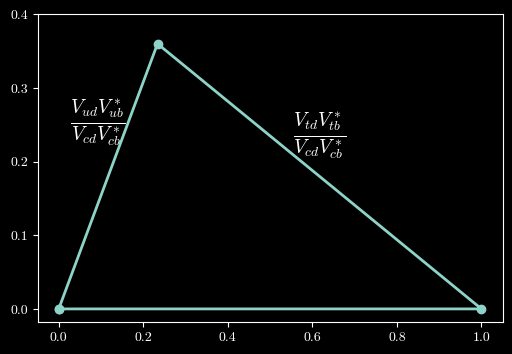

In [ ]:
import numpy as np
Theme.set("dark")

Vud, Vus, Vub = 0.974, 0.227, 0.004 * np.exp(-1j * np.deg2rad(57))
Vcd, Vcs, Vcb = 0.227, 0.973, 0.04
Vtd, Vts, Vtb = 0.008 * np.exp(-1j * np.deg2rad(57)), 0.04, 0.999

A = Vud * np.conj(Vub) / (Vcd * np.conj(Vcb))
B = 1  # единичный вектор (середина)
C = Vtd * np.conj(Vtb) / (Vcd * np.conj(Vcb))

z0 = 0
z1 = B
z2 = A

triangle = np.array([z0, z1, z2, z0])


plt.figure(figsize=(6,4))

plt.plot(triangle.real, triangle.imag, '-o', lw=2)

Ztext = 0.75*z2+0.38*z1
plt.text(Ztext.real, Ztext.imag, '$\\frac{V_{td}V_{tb}^*}{V_{cd}V_{cb}^*}$', fontsize=20, ha='left', va='top')
Ztext1 = 0.8*z2-0.16
plt.text(Ztext1.real, Ztext1.imag, '$\\frac{V_{ud}V_{ub}^*}{V_{cd}V_{cb}^*}$', fontsize=20, ha='left', va='top')

plt.yticks([0,0.1,0.2,0.3,0.4])
plt.axis()
plt.savefig('../docs/KaonDecay/CKM/images/unitary-triangle-d.svg',transparent=True)
plt.show()



## Diagramm n->p

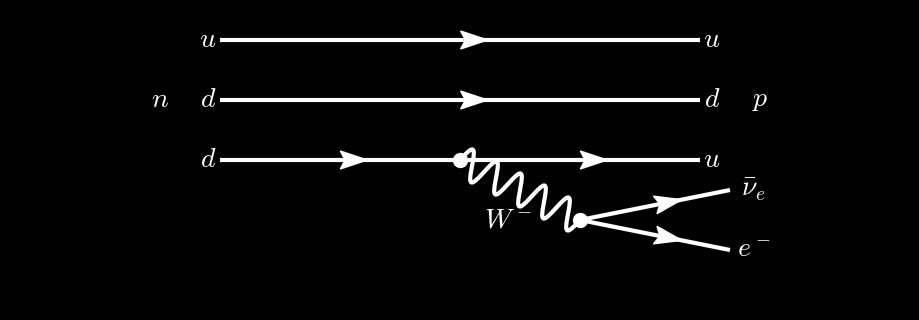

In [198]:


#Theme.set("light")
Theme.set("dark")

main_color = Theme.color()
style_params = {"color": main_color}

fig = plt.figure(figsize=(15*0.6,5*0.6))
ax = fig.add_axes([0,0,1,1 ], frameon=False)

dX = 0.25
ax.set_xlim(0, 1.5)
ax.set_ylim(0, 0.5)

# Создаём диаграмму
diagram = Diagram(ax)

image_h = 0.5
# Вершины
in1 = diagram.vertex(xy=(dX+0.1, image_h-0.05), marker='', **style_params)  # u-кварк нейтрона
in2 = diagram.vertex(xy=(dX+0.1, image_h-0.15), marker='', **style_params)  # d-кварк нейтрона
in3 = diagram.vertex(xy=(dX+0.1, image_h-0.25), marker='', **style_params)  # d-кварк нейтрона

out1 = diagram.vertex(xy=(dX+0.9, image_h-0.05), marker='', **style_params)  # u-кварк протона
out2 = diagram.vertex(xy=(dX+0.9, image_h-0.15), marker='', **style_params)  # d-кварк протона
out3 = diagram.vertex(xy=(dX+0.9, image_h-0.25), marker='', **style_params)  # u-кварк протона

v1 = diagram.vertex(xy=(dX+0.5, image_h-0.25), **style_params)  # W
v2 = diagram.vertex(xy=(dX+0.7, image_h-0.35), **style_params)  # W

out_e = diagram.vertex(xy=(dX+0.95, image_h-0.4), marker='', **style_params)   # электрон
out_nu = diagram.vertex(xy=(dX+0.95, image_h-0.3), marker='', **style_params)  # антинейтрино

# Линии кварков
u_line = diagram.line(in1, out1, **style_params, arrow_param=style_params)
d_line1 = diagram.line(in2, out2, **style_params, arrow_param=style_params)
d_line2 = diagram.line(in3, v1, **style_params, arrow_param=style_params)
u_out = diagram.line(v1, out3, **style_params, arrow_param=style_params)

# W-бозон
w_line = diagram.line(v1, v2, style='wiggly', **style_params)
nu_line = diagram.line(v2, out_nu, arrow=True, **style_params, arrow_param=style_params)
vd_line = diagram.line(v2, out_e, **style_params, arrow_param=style_params)

# Текст
diagram.text(dX+0.08, image_h-0.05, r"$u$", fontsize=20)
diagram.text(dX+0.08, image_h-0.15, r"$d$", fontsize=20)
diagram.text(dX+0.08, image_h-0.25, r"$d$", fontsize=20)

diagram.text(dX+0.92, image_h-0.05, r"$u$", fontsize=20)
diagram.text(dX+0.92, image_h-0.15, r"$d$", fontsize=20)
diagram.text(dX+0.92, image_h-0.25, r"$u$", fontsize=20)


diagram.text(v1.xy[0]+0.08, v2.xy[1], r"$W^-$", fontsize=20)
diagram.text(out_e.xy[0]+0.04, out_e.xy[1], r"$e^-$", fontsize=20)
diagram.text(out_nu.xy[0]+0.04, out_nu.xy[1], r"$\bar{\nu}_e$", fontsize=20)
diagram.text(dX+1, image_h-0.15, r"$p$", fontsize=20)
diagram.text(dX, image_h-0.15, r"$n$", fontsize=20)
# Отображаем диаграмму
diagram.plot()
fig.savefig(f'../docs/KaonDecay/CKM/images/n-decay-{Theme.suff()}.svg',transparent=True)

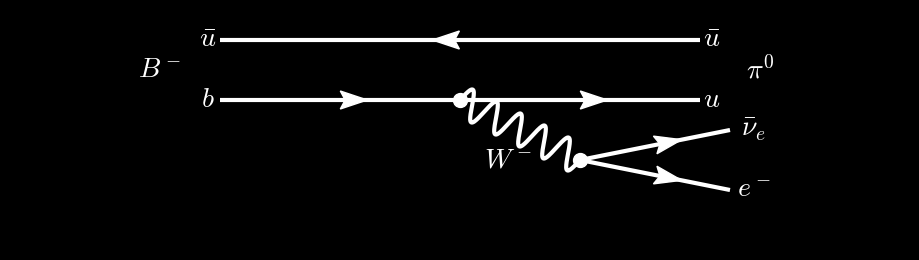

In [203]:

#Theme.set("light")
Theme.set("dark")

main_color = Theme.color()
style_params = {"color": main_color}

fig = plt.figure(figsize=(15*0.6,4*0.6))
ax = fig.add_axes([0,0,1,1 ], frameon=False)

dX = 0.25
ax.set_xlim(0, 1.5)
ax.set_ylim(0, 0.4)

# Создаём диаграмму
diagram = Diagram(ax)

image_h = 0.4
# Вершины
in1 = diagram.vertex(xy=(dX+0.1, image_h-0.05), marker='', **style_params)  # u-кварк нейтрона
in2 = diagram.vertex(xy=(dX+0.1, image_h-0.15), marker='', **style_params)  # d-кварк нейтрона=

out1 = diagram.vertex(xy=(dX+0.9, image_h-0.05), marker='', **style_params)  # u-кварк протона
out2 = diagram.vertex(xy=(dX+0.9, image_h-0.15), marker='', **style_params)  # d-кварк протона=

v1 = diagram.vertex(xy=(dX+0.5, image_h-0.15), **style_params)  # W
v2 = diagram.vertex(xy=(dX+0.7, image_h-0.25), **style_params)  # W

out_e = diagram.vertex(xy=(dX+0.95, image_h-0.3), marker='', **style_params)   # электрон
out_nu = diagram.vertex(xy=(dX+0.95, image_h-0.2), marker='', **style_params)  # антинейтрино

# Линии кварков
u_line = diagram.line(out1, in1, **style_params, arrow_param=style_params)
d_line2 = diagram.line(in2, v1, **style_params, arrow_param=style_params)
u_out = diagram.line(v1, out2, **style_params, arrow_param=style_params)

# W-бозон
w_line = diagram.line(v1, v2, style='wiggly', **style_params)
nu_line = diagram.line(v2, out_nu, arrow=True, **style_params, arrow_param=style_params)
vd_line = diagram.line(v2, out_e, **style_params, arrow_param=style_params)

# Текст
diagram.text(dX+0.08, image_h-0.05, r"$\bar{u}$", fontsize=20)
diagram.text(dX+0.08, image_h-0.15, r"$b$", fontsize=20)

diagram.text(dX+0.92, image_h-0.05, r"$\bar{u}$", fontsize=20)
diagram.text(dX+0.92, image_h-0.15, r"$u$", fontsize=20)


diagram.text(v1.xy[0]+0.08, v2.xy[1], r"$W^-$", fontsize=20)
diagram.text(out_e.xy[0]+0.04, out_e.xy[1], r"$e^-$", fontsize=20)
diagram.text(out_nu.xy[0]+0.04, out_nu.xy[1], r"$\bar{\nu}_e$", fontsize=20)
diagram.text(dX+1, image_h-0.1, r"$\pi^0$", fontsize=20)
diagram.text(dX, image_h-0.1, r"$B^-$", fontsize=20)
# Отображаем диаграмму
diagram.plot()
fig.savefig(f'../docs/KaonDecay/CKM/images/B-decay-{Theme.suff()}.svg',transparent=True)

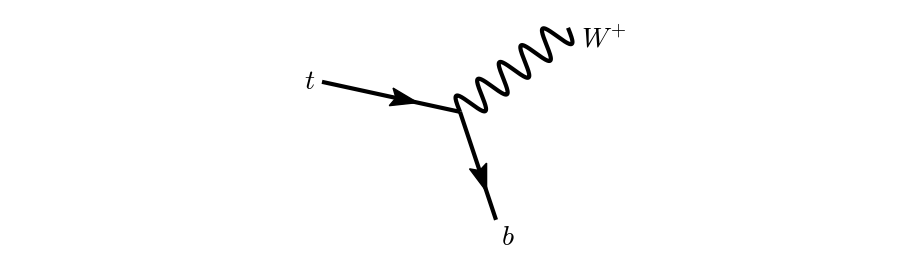

In [219]:
Theme.set("light")
#Theme.set("dark")

main_color = Theme.color()
style_params = {"color": main_color}

fig = plt.figure(figsize=(15*0.6,4*0.6))
ax = fig.add_axes([0,0,1,1 ], frameon=False)

dX = 0.25
ax.set_xlim(0, 1.5)
ax.set_ylim(0, 0.4)

# Создаём диаграмму
diagram = Diagram(ax)

image_h = 0.4
cw= 0.75
# Вершины
in1 = diagram.vertex(xy=(cw-0.23, 0.28), marker='', **style_params) 
cener = diagram.vertex(xy=(cw, 0.23), marker='', **style_params) 
outW = diagram.vertex(xy=(cw+0.18, 0.37), marker='', **style_params)  
outq = diagram.vertex(xy=(cw+0.06, 0.05), marker='', **style_params)  


tin_line = diagram.line(in1, cener, **style_params, arrow_param=style_params)
qout_line = diagram.line(cener, outq, **style_params, arrow_param=style_params)
w_line = diagram.line(cener, outW, style='wiggly', **style_params)

diagram.text(in1.xy[0]-0.02, in1.xy[1], r"$t$", fontsize=20)
diagram.text(outq.xy[0]+0.02, outq.xy[1]-0.03, r"$b$", fontsize=20)
diagram.text(outW.xy[0]+0.06, outW.xy[1]-0.02, r"$W^{+}$", fontsize=20)
# Отображаем диаграмму
diagram.plot()
fig.savefig(f'../docs/KaonDecay/CKM/images/tq-decay-{Theme.suff()}.svg',transparent=True)